Etape 1 : Ingestion et nettoyage des données

SPY → marché actions américain
QQQ → Nasdaq / tech / growth
TLT → obligations américaines long terme
GLD → or
USO → pétrole

In [21]:
import yfinance as yf

tickers = ["SPY", "TLT", "GLD", "USO", "QQQ"] 


data = yf.download(tickers, period="5y", auto_adjust=True)["Close"] #prix au close
data


[*********************100%***********************]  5 of 5 completed


Ticker,GLD,QQQ,SPY,TLT,USO
Date,,,,,
2021-09-03,171.059998,370.309509,423.462616,124.220268,48.660000
2021-09-07,167.710007,370.833588,421.948395,123.172363,48.040001
2021-09-08,167.289993,369.542938,421.434357,124.010658,48.590000
2021-09-09,168.029999,368.271606,419.630463,125.511154,47.750000
2021-09-10,167.179993,365.476624,416.321869,124.404648,48.799999
...,...,...,...,...,...
2026-08-28,408.890015,716.429993,769.349976,82.563622,129.699997
2026-08-31,408.420013,716.760010,767.049988,82.204994,133.699997
2026-09-01,396.750000,707.640015,761.780029,81.870003,141.000000


In [22]:
#rendements journaliers
returns = data.pct_change().dropna()  #on supprime la premiere ligne elle sera vide



#sauvegarde
returns.to_parquet("returns.parquet")

returns

Ticker,GLD,QQQ,SPY,TLT,USO
Date,,,,,
2021-09-07,-0.019584,0.001415,-0.003576,-0.008436,-0.012741
2021-09-08,-0.002504,-0.003480,-0.001218,0.006806,0.011449
2021-09-09,0.004423,-0.003440,-0.004280,0.012100,-0.017288
2021-09-10,-0.005059,-0.007589,-0.007885,-0.008816,0.021990
2021-09-13,0.003350,-0.000691,0.002559,0.006065,0.013934
...,...,...,...,...,...
2026-08-28,-0.032442,-0.006490,-0.002269,-0.003007,-0.002384
2026-08-31,-0.001149,0.000461,-0.002990,-0.004344,0.030840
2026-09-01,-0.028574,-0.012724,-0.006870,-0.004075,0.054600


Etape 2 : Analyse exploratoire EDA

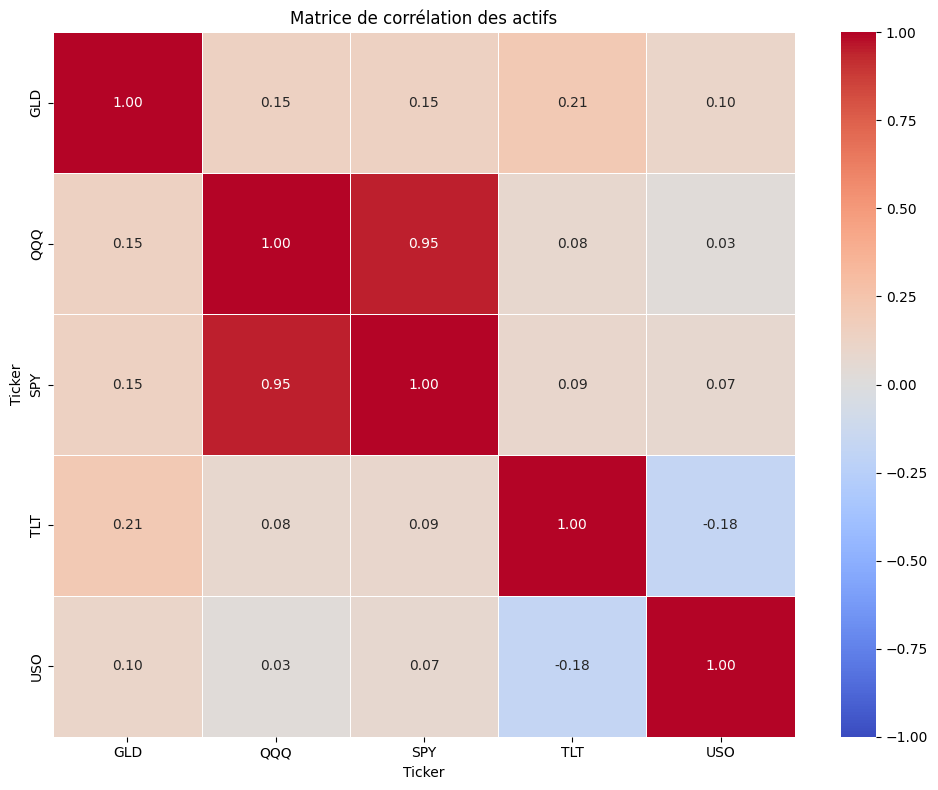

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

corr = returns.corr()

#matrice de correlation
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Matrice de corrélation des actifs")
plt.tight_layout()
plt.show()

On remarque qu'il n'ya presque pas de correlatrion entre les actifs (toute proche de 0), quoique les actions US et actions TECH sont évoluent fortement dans le même sens (0.95 proche de 1). Ce qui me semble logique car le marché des actions US est de loin majoritairement dominé par les grosses boîtes de TECH (NVIDIA, Apple, Microsoft...)

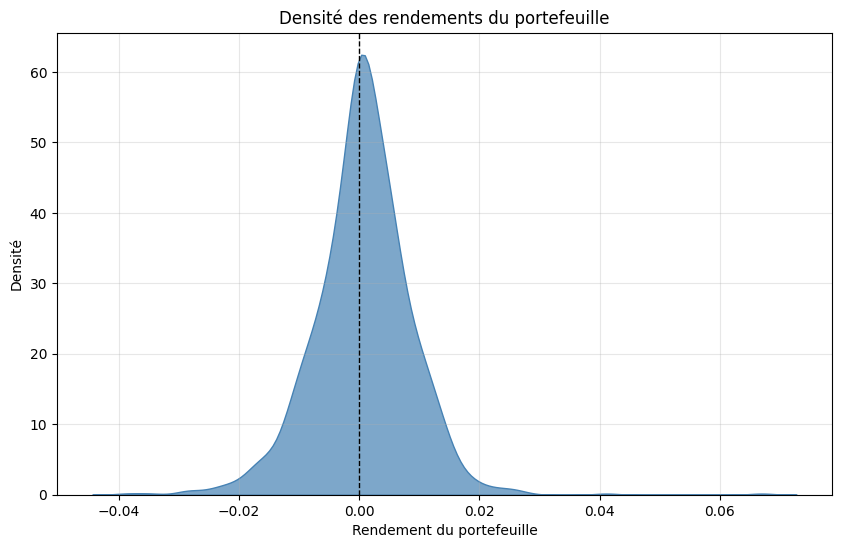

In [24]:
#courbe de densité des rendements du portefeuille
import numpy as np

# Portefeuille équipondéré 20%
poids = np.array([1/5, 1/5, 1/5, 1/5, 1/5])

#rendement du portefeuille  = somme pondérée des rendements
portfolio_return = returns.dot(poids)

# Courbe de densité
plt.figure(figsize=(10, 6))
sns.kdeplot(portfolio_return, fill="True", color="steelblue", alpha=0.7)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Densité des rendements du portefeuille")
plt.xlabel("Rendement du portefeuille")
plt.ylabel("Densité")
plt.grid(True, alpha=0.3)
plt.show()

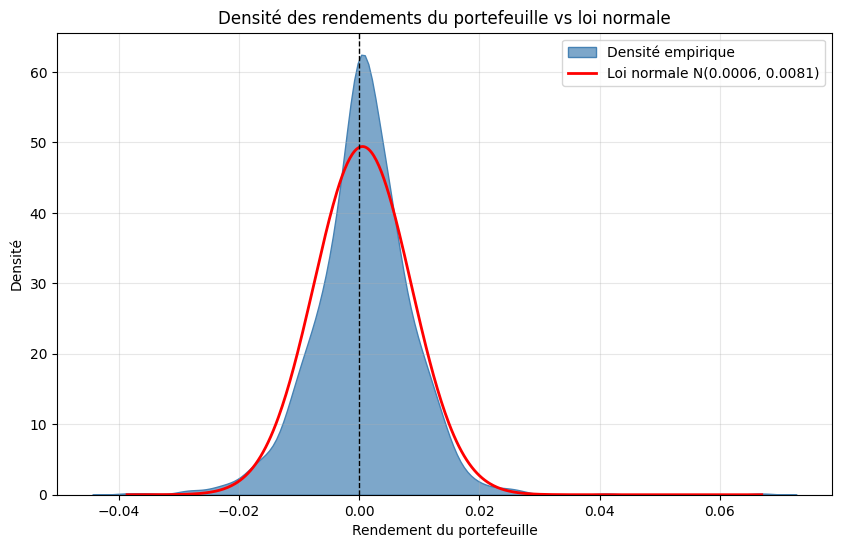

In [25]:
# superposition avec une loi normale de meme moyenne/ecart-type
from scipy import stats

#parametres de la loi normale
mu = portfolio_return.mean()
sigma = portfolio_return.std(ddof=1)

# Grille pour la courbe de densité normale
x = np.linspace(portfolio_return.min(), portfolio_return.max(), 500)

# Graphique
plt.figure(figsize=(10, 6))

# Densité empirique du portefeuille
sns.kdeplot(portfolio_return, fill=True, color="steelblue", alpha=0.7, label="Densité empirique")

# Loi normale de même moyenne / écart-type
plt.plot(
    x,
    stats.norm.pdf(x, loc=mu, scale=sigma),
    color="red",
    linewidth=2,
    label=f"Loi normale N({mu:.4f}, {sigma:.4f})"
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Densité des rendements du portefeuille vs loi normale")
plt.xlabel("Rendement du portefeuille")
plt.ylabel("Densité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Analyse de la distribution des rendements

Le pic de la densité des rendements du portfolio est 12% plus élevé que le pic d'une loi normale de même écart-type et de même moyenne. 
De plus, la densité des rendements du portfolio présente des queues légèrement plus épaisses que la loi normale.

In [26]:

# Skewness (asymétrie)
skewness = stats.skew(portfolio_return)

# Kurtosis (excès de kurtosis, par défaut dans scipy = Fisher)
kurtosis = stats.kurtosis(portfolio_return)

print(f"Skewness du portefeuille : {skewness:.6f}")
print(f"Kurtosis du portefeuille : {kurtosis:.6f}")

Skewness du portefeuille : 0.194259
Kurtosis du portefeuille : 5.066553


Le kurtosis est de 5,072775 soit 2 fois plus qu'une loi normale (généralement 3). 
Ce qui confirme les observations plus haut par rapports aux fat tails (les queues plus épaisses) et au pic central plus haut. 
Il en ressort que le portfolio est plutôt stable au quotidien avec des potentiels chocs extrêmes positifs comme négatifs plus important que ce que prévoit la normale. La skewness de 0.197325 indique qu'on devrait s'attendre plutôt à des chocs positifs.

Calcul de la VaR (3 méthodes)
Pour un horizon 1 jour, confiance 95% et 99% :

In [27]:
#VaR paramétrique
from scipy.stats import norm
#on suppose que les rendements du portfolio suivent une loi normale
# parametres : moyennne mu, quantile z, et volatilité sigma (ecart-type)

def calcul_var(returns_, confiance):
    mu = np.mean(returns_)
    z = norm.ppf(1 - confiance)
    sigma = np.std(returns_, ddof = 1)
    var = -(mu + z*sigma)
    return var

print("VaR paramétrique confiance 95 % : ", calcul_var(portfolio_return, 0.95))
print("VaR paramétrique confiance 99 % : ", calcul_var(portfolio_return, 0.99))

VaR paramétrique confiance 95 % :  0.01272060076186752
VaR paramétrique confiance 99 % :  0.01822131771236797


In [28]:
#var historique 
# le quantile empirique des rendements passés (pas d’hypothèse de distribution).
print(f"VaR historique confiance 95 % : {np.quantile(portfolio_return, 0.05)}" )
print(f"VaR historique confiance 99 % : {np.quantile(portfolio_return, 0.01)}" )

VaR historique confiance 95 % : -0.01229936910334786
VaR historique confiance 99 % : -0.020823261823807695


In [29]:
#var Monte Carlo
# Paramètres de simulation
n_scenarios = 10_000
confiances = [0.95, 0.99]

# Moyenne et covariance des rendements des actifs
mu_actifs = returns.mean().values  #pas le rendement du portefeuille mais celui des actifs
cov_actifs = returns.cov().values

# Simulation des rendements des actifs
simulations_actifs = np.random.multivariate_normal(
    mean=mu_actifs,
    cov=cov_actifs,
    size=n_scenarios
)

# Rendement simulé du portefeuille
simulations_portfolio = simulations_actifs.dot(poids)

for confiance in confiances:
    quantile = np.quantile(simulations_portfolio, 1 - confiance)
    var = -quantile
    
print(
    f"VaR Monte Carlo à {confiance:.0%} : "
    f"{var: }"
)

VaR Monte Carlo à 99% :  0.01809291415031934


| Niveau de confiance | VaR paramétrique | VaR historique | VaR Monte Carlo |
|---|---:|---:|---:|
| 95% | 1.2723% | 1.2299% | 1.2846% |
| 99% | 1.8222% | 2.0823% | 1.8951% |

La VaR à 99% donnée par la méthode historique est supérieure à celles données par les autres méthodes (1.82% < 1.85% <2.08%).

Il en ressort que le portfolio fait des pertes plus importantes que ce qui est attendu théoriquement. Les méthodes de calcul paramétrique et de Monte Carlo masquent la réalité car elles ne prennent pas en compte la tension réelle du marché. 

Rappelons que la méthode paramétrique suppose une distribution normale des rendements, la méthode Monte Carlo simule 10000 scénarios aléatoires possibles mais qui peuvent ne pas réfléter des comportements réels du portfolio. 

Nous allons backtester la VaR. 

Etape 4 : Backtesting de la VaR

backtest niveau de confiance 99%

In [30]:

"""
Compte les rendements inférieurs au seuil de perte de chaque VaR.
niveau de confiance 99%
Une exception correspond à : rendement réel < -VaR.
"""
VAR_PARAMETRIQUE_99 = calcul_var(portfolio_return, 0.99)
VAR_HISTORIQUE_99 = 0.020830181128363878
VAR_MONTE_CARLO_99 = 0.018951352166484754

def calculer_exceptions(var, portfolio_return):
    return (portfolio_return < -var).sum()
    
print(f"{calculer_exceptions(VAR_PARAMETRIQUE_99, portfolio_return)} exceptions pour la méthode paramétrique à 99% de confiance")
        
print(f"{calculer_exceptions(VAR_HISTORIQUE_99, portfolio_return)} exceptions pour la méthode historique à 99% de confiance")

print(f"{calculer_exceptions(VAR_MONTE_CARLO_99, portfolio_return)} exceptions pour la méthode Monte Carlo à 99% de confiance")


19 exceptions pour la méthode paramétrique à 99% de confiance
13 exceptions pour la méthode historique à 99% de confiance
17 exceptions pour la méthode Monte Carlo à 99% de confiance


backtest niveau de confiance 95%

In [31]:
"""
Compte les rendements inférieurs au seuil de perte de chaque VaR.
niveau de confiance 95%
Une exception correspond à : rendement réel < -VaR.
"""
VAR_PARAMETRIQUE_95 = calcul_var(portfolio_return, 0.95)
VAR_HISTORIQUE_95 = 0.012306760637989545
VAR_MONTE_CARLO_95 = 0.01284682048312342

def calculer_exceptions(var, portfolio_return):
    return (portfolio_return < -var).sum()
    
print(f"{calculer_exceptions(VAR_PARAMETRIQUE_95, portfolio_return)} exceptions pour la méthode paramétrique à 95% de confiance")
        
print(f"{calculer_exceptions(VAR_HISTORIQUE_95, portfolio_return)} exceptions pour la méthode historique à 95% de confiance")

print(f"{calculer_exceptions(VAR_MONTE_CARLO_95, portfolio_return)} exceptions pour la méthode Monte Carlo à 95% de confiance")


58 exceptions pour la méthode paramétrique à 95% de confiance
63 exceptions pour la méthode historique à 95% de confiance
56 exceptions pour la méthode Monte Carlo à 95% de confiance


Pour les 1254 jours , on doit s'attendre environ à 63 jours d'exceptiopns pour la VaR à 95% et environ 13 jours d'exceptions pour la VaR à 99%.

Pour la VaR 99%, les méthodes paramétrique et historique ont des jours d'exceptions presque 6 fois supérieures à ce qui est théoriquement attendu. Ces modèles de VaR sous-estiment de loin le risque réel. C'est ce que laissait présager les fat tails remarquées dans la distribution des rendements du portefeuille. Ce dernier est bien plus risqué qu'il n'en a l'air. Seul le modèle de Monte Carlo se rapproche de la réalité théorique à 5 jours d'exception près.

Pour la VaR 95%, les méthodes paramétrique et historique sur-estiement le risque réel. 
Le modèle Monte Carlo se rapproche un peu plus de la réalité théorique à 7 jours près. 

Il ressort que la méthode de Monte Carlo serait celui qui permet d'évaluer le plus fidèlement possible la VaR. A vérifier avec un test de KUPIEC.


TEST DE KUPIEC

In [32]:
# Test de Kupiec : test de couverture inconditionnelle
#
# H0 : la fréquence observée des exceptions correspond à la fréquence théorique
#      attendue, soit 1 - niveau_de_confiance.
# H1 : la fréquence observée des exceptions est différente.
#
# Une exception correspond à un rendement réel inférieur à -VaR.
# La statistique LR suit asymptotiquement une loi du Chi-deux à 1 degré de liberté.

def test_kupiec(var, rendements, niveau_confiance, alpha_test=0.05):
    n_observations = len(rendements)
    n_exceptions = int((rendements < -var).sum())

    probabilite_theorique = 1 - niveau_confiance
    probabilite_observee = n_exceptions / n_observations

    # Log-vraisemblance binomiale, avec gestion des cas limites
    def log_vraisemblance(k, n, p):
        resultat = 0
        if k > 0:
            resultat += k * np.log(p)
        if n - k > 0:
            resultat += (n - k) * np.log(1 - p)
        return resultat

    # Vraisemblance sous H0 et sous H1
    log_L0 = log_vraisemblance(
        n_exceptions, n_observations, probabilite_theorique
    )
    log_L1 = log_vraisemblance(
        n_exceptions, n_observations, probabilite_observee
    )

    # Statistique du rapport de vraisemblance de Kupiec
    LR_uc = 2 * (log_L1 - log_L0)

    # P-value selon une loi du Chi-deux à 1 degré de liberté
    p_value = 1 - stats.chi2.cdf(LR_uc, df=1)

    return {
        "VaR": var,
        "Confiance": niveau_confiance,
        "Observations": n_observations,
        "Exceptions": n_exceptions,
        "Exceptions attendues": n_observations * probabilite_theorique,
        "Fréquence observée": probabilite_observee,
        "Statistique LR": LR_uc,
        "p-value": p_value,
        "Décision": (
            "Rejet de H0"
            if p_value < alpha_test
            else "Non-rejet de H0"
        )
    }


# VaR à 95 %
resultats_95 = [
    test_kupiec(VAR_PARAMETRIQUE_95, portfolio_return, 0.95),
    test_kupiec(VAR_HISTORIQUE_95, portfolio_return, 0.95),
    test_kupiec(VAR_MONTE_CARLO_95, portfolio_return, 0.95)
]

# VaR à 99 %
resultats_99 = [
    test_kupiec(VAR_PARAMETRIQUE_99, portfolio_return, 0.99),
    test_kupiec(VAR_HISTORIQUE_99, portfolio_return, 0.99),
    test_kupiec(VAR_MONTE_CARLO_99, portfolio_return, 0.99)
]

# Présentation des résultats
colonnes = [
    "VaR", "Confiance", "Observations", "Exceptions",
    "Exceptions attendues", "Fréquence observée",
    "Statistique LR", "p-value", "Décision"
]

resultats_95_df = pd.DataFrame(resultats_95, index=[
    "Paramétrique", "Historique", "Monte Carlo"
])[colonnes]

resultats_99_df = pd.DataFrame(resultats_99, index=[
    "Paramétrique", "Historique", "Monte Carlo"
])[colonnes]

print("Test de Kupiec à 95 %")
display(resultats_95_df)

print("Test de Kupiec à 99 %")
display(resultats_99_df)

Test de Kupiec à 95 %


,VaR,Confiance,Observations,Exceptions,Exceptions attendues,Fréquence observée,Statistique LR,p-value,Décision
Paramétrique,0.012721,0.95,1254,58,62.7,0.046252,0.379980,0.537614,Non-rejet de H0
Historique,0.012307,0.95,1254,63,62.7,0.050239,0.001509,0.969017,Non-rejet de H0
Monte Carlo,0.012847,0.95,1254,56,62.7,0.044657,0.780518,0.376983,Non-rejet de H0


Test de Kupiec à 99 %


,VaR,Confiance,Observations,Exceptions,Exceptions attendues,Fréquence observée,Statistique LR,p-value,Décision
Paramétrique,0.018221,0.99,1254,19,12.54,0.015152,2.903260,0.088401,Non-rejet de H0
Historique,0.020830,0.99,1254,13,12.54,0.010367,0.016842,0.896744,Non-rejet de H0
Monte Carlo,0.018951,0.99,1254,17,12.54,0.013557,1.441895,0.229833,Non-rejet de H0


Etape 5 : Machine Learning : détection de régime de volatilité 

Sommes-nous	dans	un	régime	de	marché	calme	ou	stressé	?	(classification	ML,	utile	pour
ajuster	dynamiquement	les	limites	de	risque)

 - Ajout d'un feature variable high_vol = 1 si	la	volatilité	réalisée sur	les	5	prochains	jours dépasse	le	75e	percentile	historique,	sinon 0

In [33]:

"""
Pour chaque jour t, high_vol[t] = 1 si les 5 jours après t ont été agités (dans le quart le plus volatile de toute l'historique), sinon 0
C'est la variable à prédire, on va l'utiliser pour entrainer le passé
"""
#volatilité réalisée sur les 5 prochains jours
vol_realisee_future = portfolio_return.rolling(5).std().shift(-5)  #shift négatif pour indiquer le futur

#seuil = 75e percentile de la volatilité future, sur toute l'historique
seuil = vol_realisee_future.quantile(0.75)

#variable cible binaire
high_vol = (vol_realisee_future > seuil).astype(int)

 - Construction des features

In [34]:
"""
Explication du drawdown, puisque c'est nouveau : cumulative reconstitue la valeur du portefeuille dans le temps (en partant de 1). 
running_max retient le plus haut niveau jamais atteint jusqu'à ce jour. 
e drawdown, c'est "de combien on a chuté par rapport à ce plus haut" — toujours négatif ou nul. 
Un drawdown de -0.15 veut dire "on est 15% en dessous du pic historique récent". 
C'est une feature utile parce qu'un marché déjà en forte baisse a souvent tendance à rester volatil.

"""
features = pd.DataFrame(index=portfolio_return.index)

#vol réalisée sur les 5 derniers jours (passé, pas de shift)
features["vol_5j"] = portfolio_return.rolling(window= 5).std()

#vol réalisée sur les 20 derniers jours
features["vol_20j"] = portfolio_return.rolling(window = 20).std()

#rendement moyen glissant sur 20 jours
features["rendement_moyen_glissant_20j"] = portfolio_return.rolling(window = 20).mean()

#drawdown courant  : à quel point on est loin du plus haut historique récent
cumulative = (1 + portfolio_return).cumprod()
running_max = cumulative.cummax()
features["drawdown"] = (cumulative - running_max) / running_max



 - régression	logistique	ET random	forest training

In [35]:
X = features #features
y = high_vol #cible

data_ml = pd.concat([X, y.rename("high_vol")], axis=1).dropna() #garanti que X et y restent parfaitement synchronisés ligne par ligne.
data_ml

X = data_ml.drop(columns=["high_vol"])
y = data_ml["high_vol"]

- split chronologique (jamais aléatoire)


In [36]:
split_index = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

Pourquoi pas train_test_split avec mélange aléatoire : sur une série temporelle, mélanger reviendrait à entraîner le modèle en lui montrant parfois des jours de 2026 avant de tester sur des jours de 2022, ce qui n'a aucun sens (dans la réalité, tu ne connais jamais le futur au moment de l'entraînement). 
L
e split chronologique simple (80% des premières dates pour l'entraînement, 20% des dernières pour le test) reproduit une vraie situation de prédiction.

 - training 

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# La régression logistique est sensible à l'échelle des features → on standardise
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Le random forest n'a pas besoin de standardisation (il est basé sur des seuils, pas des distances)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

 - Evaluer le recall par classe, AUC, courbe ROC 

--- Régression logistique ---
                 precision    recall  f1-score   support

Vol normale (0)       0.74      0.97      0.84       182
 Vol élevée (1)       0.25      0.03      0.05        65

       accuracy                           0.72       247
      macro avg       0.49      0.50      0.45       247
   weighted avg       0.61      0.72      0.63       247

AUC : 0.616

--- Random Forest ---
                 precision    recall  f1-score   support

Vol normale (0)       0.75      0.88      0.81       182
 Vol élevée (1)       0.35      0.18      0.24        65

       accuracy                           0.70       247
      macro avg       0.55      0.53      0.53       247
   weighted avg       0.65      0.70      0.66       247

AUC : 0.649



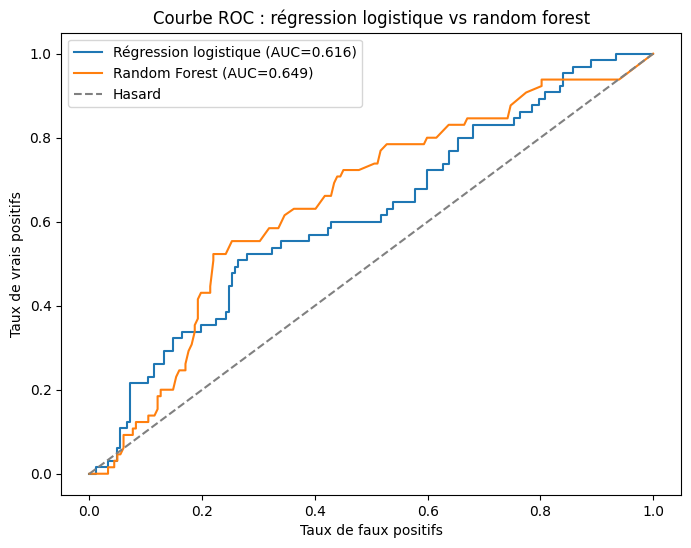

In [38]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

for nom, modele, X_te in [("Régression logistique", log_reg, X_test_scaled), ("Random Forest", rf, X_test)]:
    y_pred = modele.predict(X_te)
    y_proba = modele.predict_proba(X_te)[:, 1]

    print(f"--- {nom} ---")
    print(classification_report(y_test, y_pred, target_names=["Vol normale (0)", "Vol élevée (1)"]))
    print(f"AUC : {roc_auc_score(y_test, y_proba):.3f}\n")

# Courbes ROC superposées
plt.figure(figsize=(8, 6))
for nom, modele, X_te in [("Régression logistique", log_reg, X_test_scaled), ("Random Forest", rf, X_test)]:
    y_proba = modele.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nom} (AUC={roc_auc_score(y_test, y_proba):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hasard")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC : régression logistique vs random forest")
plt.legend()
plt.show()

Les recall des 2 modèles pour prédire un stress sont relativement bas (65 jours prédits sur 247 jours). 
Avec ces 4 features (volatilité glissante, rendement moyen, drawdown), les modèles ne parviennent pas à détecter significativement mieux qu'un modèle naïf le régime de volatilité à 5 jours. 
Ceci suggère soit que le signal prédictif de ces features est trop faible pour cet horizon, soit qu'il manque des variables informatives (le VIX, qu'on avait identifié comme piste, capture justement une dimension — le sentiment de marché — absente de ces 4 features basées uniquement sur les rendements du portefeuille lui-même).
On pourrait améliorer le modèle en rajoutant le VIX. 